In [6]:
# protocol for studies of microscale editing

import networkx as nx
import matplotlib
from matplotlib import pyplot as plt
from collections import defaultdict 
import numpy as np
import pandas as pd

reads_taf_files    = ['RPS12_mapped_reads.taf', 'ND8_mapped_reads.taf', 'ND3_mapped_reads.taf', 'ND9_mapped_reads.taf', 'G4_mapped_reads.taf', 'G3_mapped_reads.taf']
refs_fasta_files   = ['./refs_crypto/18_RPS12.fa', './refs_crypto/3_ND8.fa', './refs_crypto/17_G5.fa', './refs_crypto/4_ND9.fa', './refs_crypto/15_G4.fa', './refs_crypto/10_G3.fa']
grna_mrna_mappings = ['rps12.grna_in_reads.good_a2', 'nd8.grna_in_reads.good_a2', 'nd3.grna_in_reads.good', 'nd9.grna_in_reads.good', 'g4.grna_in_reads.good', 'g3.grna_in_reads.good']
genes = ['RPS12', 'ND8', 'ND3', 'ND9', 'G4', 'G3']

gRNA_data = pd.read_excel('../final_draft/revision 1/submit/Sara/Supplementary TablesSZdone.xlsx', sheet_name='Table S4', skiprows=[0], header=0)

grnas_assignments = {}
for i, j, k, l in zip(gRNA_data['Minicircle'].tolist(), gRNA_data['Locus'].tolist(), gRNA_data['Gene'].tolist(), gRNA_data['gRNA gene sequence'].tolist()):
    grnas_assignments[l] = [i,j,k]

starts_of_read_mappings = defaultdict(lambda : defaultdict(lambda : 0))
mapped_read_seqs = defaultdict(lambda : defaultdict(lambda : ''))


for gene, taf in zip(genes, reads_taf_files):
    with open(taf, 'r') as ifile:
        for line in ifile:
            toks = line.split('\t')
            starts_of_read_mappings[gene][toks[1][4:]] = int(toks[2])      
            mapped_read_seqs[gene][toks[1][4:]] = toks[5].rstrip() 
    
    


In [7]:

editing_events_by_gRNA = defaultdict(lambda : defaultdict(lambda : [0, defaultdict(lambda : 0)]))
editing_events_by_gRNA_stats = defaultdict(lambda : defaultdict(lambda : [0, 0, 0, 0]))

for gene, grna_align in zip(genes, grna_mrna_mappings):
    with open(grna_align, 'r') as ifile:
        for line in ifile:
            toks = line.split('\t')
            rd = toks[0]
            if 'rd' in rd:
                rd = rd[2:]
            
            rd_start = starts_of_read_mappings[gene][rd]
            rd_seq = mapped_read_seqs[gene][rd]
            tlp = 0
            i = 0
            
            while i < int(toks[1]):
                
                if rd_seq[i] != 'T':
                    tlp += 1
                i+= 1
            
            event_start = rd_start + tlp
            
            assn = ['!!!']
            for i in grnas_assignments:
                if toks[5] == i[int(toks[3]):int(toks[3])+len(toks[4])]:
                    assn = grnas_assignments[i]
            
            mmc = 0
            guc = 0
            for m, g in zip(toks[4][1:-1], toks[5][1:-1]):
                if m != g:
                    if m == 'G' and g == 'A':
                        guc += 1
                    elif m == 'T' and g == 'C':
                        guc += 1
                    else:
                        mmc += 1
            a = len(toks[4]) - 1
            while a > 0 and toks[5][a] == toks[4][a]:
                a -= 1
            anchor = toks[5][a+1:]
            
            #event_id = '_'.join(assn)+'_'+str(len(toks[5]))
            event_id = '_'.join(assn)+'_'+anchor
            editing_events_by_gRNA[gene][event_id][0] += 1
            editing_events_by_gRNA[gene][event_id][1][toks[4]] += 1
            editing_events_by_gRNA[gene][event_id].append(anchor)
            editing_events_by_gRNA_stats[gene][event_id][0] += 1
            editing_events_by_gRNA_stats[gene][event_id][1] += len(toks[5])
            editing_events_by_gRNA_stats[gene][event_id][2] += guc
            editing_events_by_gRNA_stats[gene][event_id][3] += mmc

'''
editing_events_by_gRNA = defaultdict(lambda : defaultdict(lambda : [0, defaultdict(lambda : 0)]))

max_al = defaultdict(lambda : 0)
for gene in editing_events_by_gRNA_i:
    for event in editing_events_by_gRNA_i[gene]:
        e = '_'.join(event.split('_')[:-1])
        l = int(event.split('_')[-1])
        if max_al[e] < l:
            max_al[e] = l
            
for gene in editing_events_by_gRNA_i:
    for event in editing_events_by_gRNA_i[gene]:
        e = '_'.join(event.split('_')[:-1])
        l = int(event.split('_')[-1])
        if max_al[e] == l:
            editing_events_by_gRNA[gene][event] = editing_events_by_gRNA_i[gene][event]
'''                     

"\nediting_events_by_gRNA = defaultdict(lambda : defaultdict(lambda : [0, defaultdict(lambda : 0)]))\n\nmax_al = defaultdict(lambda : 0)\nfor gene in editing_events_by_gRNA_i:\n    for event in editing_events_by_gRNA_i[gene]:\n        e = '_'.join(event.split('_')[:-1])\n        l = int(event.split('_')[-1])\n        if max_al[e] < l:\n            max_al[e] = l\n            \nfor gene in editing_events_by_gRNA_i:\n    for event in editing_events_by_gRNA_i[gene]:\n        e = '_'.join(event.split('_')[:-1])\n        l = int(event.split('_')[-1])\n        if max_al[e] == l:\n            editing_events_by_gRNA[gene][event] = editing_events_by_gRNA_i[gene][event]\n"

In [8]:
all_canonical_GUs = []
all_non_canonical_GUs = []
all_canonical_MMs = []
all_non_canonical_MMs = []
all_canonical_LNs = []
all_non_canonical_LNs = []
ALL_can = []
ALL_non_can = []

all_non_cognate_reads = 0
all_non_canonical_cognate_reads = 0
all_cognate_reads = 0
for G in genes:
    current_gene = G
    main_path_ratios_non_canonical = []
    main_path_ratios_canonical = []
    canonical = 0
    non_canonical = 0
    canonical_multi = 0
    non_canonical_multi = 0
    for event in editing_events_by_gRNA[current_gene]:
        total_supp = editing_events_by_gRNA[current_gene][event][0]
        #if int(event.split('_')[5]) <= 22 or total_supp < 4:
        if total_supp < 4:
            continue
        is_multi = False
        if len(editing_events_by_gRNA[current_gene][event][1]) > 1:
            is_multi = True
        is_canonical = False
        if event.split('_')[4] == current_gene:
            is_canonical = True

        if is_multi and is_canonical:
            canonical_multi += 1
            all_canonical_LNs.append(float(editing_events_by_gRNA_stats[current_gene][event][1]) / float(editing_events_by_gRNA_stats[current_gene][event][0]))
            all_canonical_GUs.append(float(editing_events_by_gRNA_stats[current_gene][event][2]) / float(editing_events_by_gRNA_stats[current_gene][event][1]))
            all_canonical_MMs.append(float(editing_events_by_gRNA_stats[current_gene][event][3]) / float(editing_events_by_gRNA_stats[current_gene][event][1]))
        elif not is_multi and is_canonical:
            canonical += 1
        elif not is_multi and not is_canonical:
            non_canonical += 1
        elif is_multi and not is_canonical:
            non_canonical_multi += 1
            all_non_cognate_reads += total_supp
            all_non_canonical_LNs.append(float(editing_events_by_gRNA_stats[current_gene][event][1]) / float(editing_events_by_gRNA_stats[current_gene][event][0]))
            all_non_canonical_GUs.append(float(editing_events_by_gRNA_stats[current_gene][event][2]) / float(editing_events_by_gRNA_stats[current_gene][event][1]))
            all_non_canonical_MMs.append(float(editing_events_by_gRNA_stats[current_gene][event][3]) / float(editing_events_by_gRNA_stats[current_gene][event][1]))

        max_path = 0
        for j in editing_events_by_gRNA[current_gene][event][1]:
            if editing_events_by_gRNA[current_gene][event][1][j] > max_path:
                max_path = editing_events_by_gRNA[current_gene][event][1][j]
                
        if is_multi and is_canonical:
            all_non_canonical_cognate_reads += (total_supp - max_path)
            all_cognate_reads += total_supp
        ratio = float(max_path) / float(total_supp)
        ratio = int(100 * ratio)
        if not is_multi:
            ratio = -1
        elif not is_canonical:
            main_path_ratios_non_canonical.append(ratio)
        else:
            main_path_ratios_canonical.append(ratio)
    print(G)
    print(np.median(main_path_ratios_canonical), np.median(main_path_ratios_non_canonical))
    ALL_can.extend(main_path_ratios_canonical)
    ALL_non_can.extend(main_path_ratios_non_canonical)
    print(canonical, non_canonical, canonical_multi, non_canonical_multi)

print(np.median(ALL_can))
print(np.median(ALL_non_can))

print(all_non_canonical_cognate_reads)
print(all_non_cognate_reads)
print(all_cognate_reads)

RPS12
76.5 61.0
22 46 62 92
ND8
71.0 50.0
31 75 161 362
ND3
56.5 40.5
13 56 66 252
ND9
61.0 50.0
24 62 141 324
G4
55.5 50.0
38 58 126 196
G3
28.0 33.0
13 75 32 161
62.0
50.0
45107
150559
285514


In [10]:
TableS1 = pd.read_excel('../final_draft/revision 1/submit/Sara/Supplementary TablesSZdone.xlsx', sheet_name='Table S1', skiprows=[0], header=0)

loci_len = []
for i in TableS1['LLL'].tolist():
    if i > 0:
        loci_len.append(i)
for i in TableS1['RRR'].tolist():
    if i > 0:
        loci_len.append(i)
print(np.average(loci_len))
print(np.median(loci_len))

KeyError: 'LLL'

In [11]:
print(np.median(all_canonical_GUs))
print(np.median(all_non_canonical_GUs))
print(np.median(all_canonical_MMs))
print(np.median(all_non_canonical_MMs))
print(np.median(all_canonical_LNs))
print(np.median(all_non_canonical_LNs))

0.226335656213705
0.23300970873786409
0.06539558089807555
0.09433962264150944
28.666666666666668
26.0


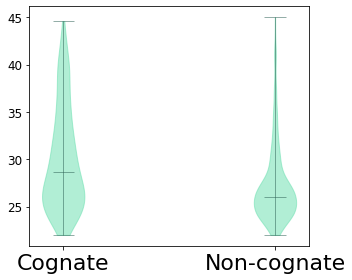

In [15]:


plt.figure(figsize=[5, 4])


bp1=plt.violinplot([all_canonical_LNs],  positions=[1], showmedians=True, widths=0.2)
bp2=plt.violinplot([all_non_canonical_LNs],  positions=[2], showmedians=True, widths=0.2)

for bp in [bp1, bp2]:
    bp['cmedians']._us_lw = np.array([0.5,])
    bp['cmedians']._linewidths = np.array([0.5,])
    bp['cmins']._us_lw = np.array([0.5,])
    bp['cmins']._linewidths = np.array([0.5,])
    bp['cmaxes']._us_lw = np.array([0.5,])
    bp['cmaxes']._linewidths = np.array([0.5,])
    bp['cbars']._us_lw = np.array([0.5,])
    bp['cbars']._linewidths = np.array([0.5,])
    
    bp['bodies'][0].set_alpha(0.5)
    bp['bodies'][0].set_color('#64deac')
    bp['cbars'].set_color('#2b5e53')
    bp['cmins'].set_color('#2b5e53')
    bp['cmaxes'].set_color('#2b5e53')
    bp['cmedians'].set_color('#2b5e53')
    
plt.xticks([1,2], ['Cognate', 'Non-cognate'])
from matplotlib import rcParams
rcParams['xtick.labelsize'] = 22
rcParams['ytick.labelsize'] = 12 
plt.tight_layout()
plt.savefig('Additional_Figure_CvsNC_gRNA_LNs.png', dpi=500)
plt.show()

In [16]:
from scipy.stats import ks_2samp
print(ks_2samp(all_canonical_GUs, all_non_canonical_GUs))
print(ks_2samp(all_canonical_MMs, all_non_canonical_MMs))
print(ks_2samp(all_canonical_LNs, all_non_canonical_LNs))

Ks_2sampResult(statistic=0.059762910210948116, pvalue=0.09963905405252527)
Ks_2sampResult(statistic=0.2387218045112782, pvalue=7.2581937432699e-21)
Ks_2sampResult(statistic=0.2796558421494048, pvalue=1.778286197280486e-28)


In [ ]:
print(1.63 * np.sqrt( (len(all_canonical_GUs) + len(all_non_canonical_GUs) ) / (len(all_canonical_GUs) * len(all_non_canonical_GUs)) ) )

In [ ]:
eee = []
for event in editing_events_by_gRNA_i['RPS12']:
    eee.append([event, editing_events_by_gRNA_i['RPS12'][event][2]])
eee.sort(key=lambda x : x[0])
for e in eee:
    print(e)